In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import sys
sys.path.append("../../utils/")

from utils import *

/home/javier/.conda/envs/tfgClean/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ===== RUTAS =====
PROJECT_ROOT = Path.cwd().resolve().parents[2]

NOMBRE_EXPERIMENTO = 'CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1'
CARPETA_DATASET = 'CIC18__split__v1'

NOMBRE_DATASET_TRAIN = f"{CARPETA_DATASET}__train.csv"
NOMBRE_DATASET_TEST = f"{CARPETA_DATASET}__test.csv"

RUTA_DATASET = PROJECT_ROOT / "02_datasets" / "processed" / CARPETA_DATASET
RUTA_RESULTADOS = PROJECT_ROOT / "04_experimentos" / "logs" / "resultados" / NOMBRE_EXPERIMENTO

NOMBRE_RESULTADOS_FOLDS_CSV = f"{NOMBRE_EXPERIMENTO}__folds_B.csv"
NOMBRE_RESULTADOS_HOLDOUT_CSV = f"{NOMBRE_EXPERIMENTO}__holdout_C.csv"
NOMBRE_RESULTADOS_RESUMEN_CSV = f"{NOMBRE_EXPERIMENTO}__tabla_resumen_B_y_C.csv"
NOMBRE_RESULTADOS_RESUMEN_JSON = f"{NOMBRE_EXPERIMENTO}__summary_B_y_C.json"

# ===== PARÁMETROS =====
LABEL_COL = "LABEL"

N_SPLITS = 5
SHUFFLE = True
RANDOM_STATE = 42

# ===== FASE 0 =====
N_VALUES = [500, 1000, 2000, 5000, 10000, 20000, 30000, 40000]

# Cambia aquí el escalador del experimento:
# "StandardScaler" o "RobustScaler"
SCALER_NAME = 'StandardScaler'

# Cambia aquí la técnica del experimento:
# "RUS_SMOTE", "RUS_SMOTE_ENN", "NearMiss_SMOTE", "NearMiss_SMOTE_ENN", etc.
ESTRATEGIA_DE_REBALANCEO = 'NearMiss_SMOTE'

DESCRIPCION_EXPERIMENTO = f"{SCALER_NAME} + PCA + {ESTRATEGIA_DE_REBALANCEO.replace('_', '/')}"

# ===== CONFIG KNN =====
N_NEIGHBORS = 5
WEIGHTS = "distance"
METRIC = "minkowski"
P = 2

# ===== CONFIG PCA =====
N_COMPONENTS_PCA = 41

# ===== CONFIG REBALANCEO =====
NEARMISS_VERSION = 1
SMOTE_K_NEIGHBORS = 5
ENN_N_NEIGHBORS = 3


In [3]:
RUTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

print("Ruta dataset train:")
print((RUTA_DATASET / NOMBRE_DATASET_TRAIN).resolve())
print()

print("Ruta dataset test:")
print((RUTA_DATASET / NOMBRE_DATASET_TEST).resolve())
print()

print("Ruta resultados:")
print(RUTA_RESULTADOS.resolve())

Ruta dataset train:
/home/javier/TFG_FASE_0/02_datasets/processed/CIC18__split__v1/CIC18__split__v1__train.csv

Ruta dataset test:
/home/javier/TFG_FASE_0/02_datasets/processed/CIC18__split__v1/CIC18__split__v1__test.csv

Ruta resultados:
/home/javier/TFG_FASE_0/04_experimentos/logs/resultados/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1


In [4]:
df_train = cargar_dataset(
    nombre_dataset=NOMBRE_DATASET_TRAIN,
    ruta_base=RUTA_DATASET
)

print("Forma del dataset train:")
print(df_train.shape)

df_train.head()

Forma del dataset train:
(1341149, 55)


,DST_PORT,PROTOCOL,FLOW_DURATION,TOT_FWD_PKTS,TOT_BWD_PKTS,TOTLEN_FWD_PKTS,TOTLEN_BWD_PKTS,FWD_PKT_LEN_MAX,FWD_PKT_LEN_MIN,FWD_PKT_LEN_MEAN,...,INIT_BWD_WIN_BYTS,FWD_ACT_DATA_PKTS,ACTIVE_MEAN,ACTIVE_STD,ACTIVE_MAX,ACTIVE_MIN,IDLE_MEAN,IDLE_MAX,IDLE_MIN,LABEL
0,2,0,44751,3,13,6733,6000,1100,0,41677,...,250,3,0,0,0,0,0,0,0,1
1,37274,4,753825,754,1064,6266,18066,1424,184,20085,...,4725,278,72650,56255,70259,43755,32542,11323,36885,3
2,2,0,4380198,1,3,3,1,3,0,3,...,3,1,0,0,0,0,0,0,0,7
3,624,0,9183,1,3,3,1,3,0,3,...,3,1,0,0,0,0,0,0,0,0
4,2,0,66089,3,13,379,1459,225,0,488,...,156,3,0,0,0,0,0,0,0,2


In [5]:
if LABEL_COL not in df_train.columns:
    raise ValueError(f"No se encontró la columna {LABEL_COL} en train")

print("Última columna train:", df_train.columns[-1])
print("Tipo de LABEL train:", df_train[LABEL_COL].dtype)
print()

print("Distribución de clases en train:")
display(df_train[LABEL_COL].value_counts(dropna=False).to_frame("count"))

Última columna train: LABEL
Tipo de LABEL train: int64

Distribución de clases en train:


,count
LABEL,
1,360000
0,360000
2,159089
3,116159
4,115628
5,111820
6,75238
7,33125
8,7926


In [6]:
X_train = df_train.drop(columns=[LABEL_COL]).copy()
y_train = df_train[LABEL_COL].copy()

print("Shape X_train:", X_train.shape)
print("Shape y_train:", y_train.shape)

Shape X_train: (1341149, 54)
Shape y_train: (1341149,)


In [7]:
columnas_no_numericas_train = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Columnas no numéricas en X_train:")
print(columnas_no_numericas_train)

if len(columnas_no_numericas_train) > 0:
    raise ValueError("Hay columnas no numéricas en X_train. Revísalas antes de seguir.")

Columnas no numéricas en X_train:
[]


In [8]:
df_test = cargar_dataset(
    nombre_dataset=NOMBRE_DATASET_TEST,
    ruta_base=RUTA_DATASET
)

print("Forma del dataset test:")
print(df_test.shape)

if LABEL_COL not in df_test.columns:
    raise ValueError(f"No se encontró la columna {LABEL_COL} en test")

X_test = df_test.drop(columns=[LABEL_COL]).copy()
y_test = df_test[LABEL_COL].copy()

columnas_no_numericas_test = X_test.select_dtypes(exclude=[np.number]).columns.tolist()

print("Columnas no numéricas en X_test:")
print(columnas_no_numericas_test)

if len(columnas_no_numericas_test) > 0:
    raise ValueError("Hay columnas no numéricas en X_test. Revísalas antes de seguir.")

print()
print("Distribución de clases en test:")
display(df_test[LABEL_COL].value_counts(dropna=False).to_frame("count"))

Forma del dataset test:
(335288, 55)
Columnas no numéricas en X_test:
[]

Distribución de clases en test:


,count
LABEL,
0,90000
1,90000
2,39772
3,29040
4,28907
5,27955
6,18810
7,8281
8,1982


In [9]:
def crear_scaler(nombre_scaler):
    if nombre_scaler == "StandardScaler":
        return StandardScaler()
    elif nombre_scaler == "RobustScaler":
        return RobustScaler()
    else:
        raise ValueError(f"Scaler no soportado: {nombre_scaler}")


def crear_pipeline():
    return Pipeline([
        ("knn", KNeighborsClassifier(
            n_neighbors=N_NEIGHBORS,
            weights=WEIGHTS,
            metric=METRIC,
            p=P
        ))
    ])


def calcular_metricas_clasificacion(modelo, X_eval, y_eval, y_pred, labels_globales):
    return {
        "accuracy": accuracy_score(y_eval, y_pred),

        "precision_weighted": precision_score(y_eval, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_eval, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_eval, y_pred, average="weighted", zero_division=0),

        "precision_macro": precision_score(y_eval, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_eval, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_eval, y_pred, average="macro", zero_division=0),

        "mcc": matthews_corrcoef(y_eval, y_pred),

        "roc_auc": calcular_roc_auc_multiclase_seguro(
            modelo=modelo,
            X_val=X_eval,
            y_val=y_eval,
            labels_globales=labels_globales,
            verbose=True
        )
    }


def resumir_metricas_cv(df, prefijo):
    """
    Resumen para validación CV:
    devuelve media, desviación típica y varianza entre folds.
    """
    metricas = [
        "accuracy",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "mcc",
        "roc_auc",
        "fit_time",
        "score_time"
    ]

    resumen = {}
    for metrica in metricas:
        col = f"{prefijo}_{metrica}"
        if col in df.columns:
            resumen[f"{metrica}_mean"] = float(df[col].mean())
            resumen[f"{metrica}_std"] = float(df[col].std(ddof=1))
            resumen[f"{metrica}_var"] = float(df[col].var(ddof=1))
    return resumen


def extraer_metricas_holdout(fila_holdout):
    """
    Resumen para hold-out final:
    devuelve un único valor real, sin media ni desviación típica.
    """
    metricas = [
        "accuracy",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "mcc",
        "roc_auc",
        "fit_time",
        "score_time"
    ]

    resumen = {}
    for metrica in metricas:
        col = f"C_{metrica}"
        if col in fila_holdout.index:
            resumen[metrica] = float(fila_holdout[col])
    return resumen


In [10]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=SHUFFLE,
    random_state=RANDOM_STATE
)

cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [11]:
labels_globales = np.array(sorted(pd.unique(pd.concat([y_train, y_test]))))

resultados_folds = []
resultados_holdout = []

for target_n in N_VALUES:

    print("\n" + "#" * 100)
    print(f"N = {target_n} instancias por clase")
    print("#" * 100)

    # =====================================================================================
    # 1) CROSS-VALIDATION SOLO CON EL 80% DE TRAIN
    #    En cada fold:
    #    - A = 64% entrenamiento
    #    - B = 16% validación
    #    El hold-out C NO se toca aquí.
    # =====================================================================================
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):

        print("=" * 80)
        print(f"N={target_n} | CV FOLD {fold}/{N_SPLITS}")
        print("=" * 80)

        # =========================
        # Split del fold: A y B
        # =========================
        df_train_fold = df_train.iloc[train_idx].copy()  # A
        df_val_fold = df_train.iloc[val_idx].copy()      # B

        # =========================
        # Escalado SOLO ajustado con A
        # =========================
        feature_cols = [col for col in df_train_fold.columns if col != LABEL_COL]

        X_A_original = df_train_fold[feature_cols]
        y_A_original = df_train_fold[LABEL_COL]

        X_B_original = df_val_fold[feature_cols]
        y_B = df_val_fold[LABEL_COL]

        scaler_fold = crear_scaler(SCALER_NAME)

        X_A_scaled = pd.DataFrame(
            scaler_fold.fit_transform(X_A_original),
            columns=feature_cols,
            index=df_train_fold.index
        )

        X_B_scaled = pd.DataFrame(
            scaler_fold.transform(X_B_original),
            columns=feature_cols,
            index=df_val_fold.index
        )

        pca_fold = PCA(n_components=N_COMPONENTS_PCA, random_state=RANDOM_STATE)
        pca_cols = [f"PC{i+1}" for i in range(N_COMPONENTS_PCA)]

        X_A_pca = pd.DataFrame(
            pca_fold.fit_transform(X_A_scaled),
            columns=pca_cols,
            index=df_train_fold.index
        )

        X_B = pd.DataFrame(
            pca_fold.transform(X_B_scaled),
            columns=pca_cols,
            index=df_val_fold.index
        )

        df_train_fold_pca = X_A_pca.copy()
        df_train_fold_pca[LABEL_COL] = y_A_original

        # =========================
        # Rebalanceo SOLO sobre A ya transformado por PCA
        # =========================
        df_train_fold_balanceado = rebalancear_train_fold(
            df_fold_train=df_train_fold_pca,
            label_col=LABEL_COL,
            target_n=target_n,
            random_state=RANDOM_STATE + fold,
            nearmiss_version=NEARMISS_VERSION,
            smote_k_neighbors=SMOTE_K_NEIGHBORS,
            estrategia_rebalanceo=ESTRATEGIA_DE_REBALANCEO,
            enn_n_neighbors=ENN_N_NEIGHBORS
        )

        X_A = df_train_fold_balanceado.drop(columns=[LABEL_COL])
        y_A = df_train_fold_balanceado[LABEL_COL]

        # =========================
        # Modelo nuevo para cada fold
        # Pipeline:
        # - escalado ajustado solo con A
        # - PCA ajustado solo con A escalado
        # - rebalanceo sobre A en espacio PCA
        # - fit kNN con A rebalanceado
        # - evaluación solo en B escalado y transformado por PCA
        # =========================
        pipeline_fold = crear_pipeline()

        t0 = time.time()
        pipeline_fold.fit(X_A, y_A)
        fit_time = time.time() - t0

        print("Clases en A:", sorted(pd.unique(y_A)))
        print("Clases en B:", sorted(pd.unique(y_B)))
        print("Clases del kNN:", pipeline_fold.named_steps["knn"].classes_)
        print("Shape predict_proba B:", pipeline_fold.predict_proba(X_B).shape)

        # =========================
        # Validación sobre B
        # =========================
        t0 = time.time()
        y_pred_B = pipeline_fold.predict(X_B)
        score_time_B = time.time() - t0

        metricas_B = calcular_metricas_clasificacion(
            modelo=pipeline_fold,
            X_eval=X_B,
            y_eval=y_B,
            y_pred=y_pred_B,
            labels_globales=labels_globales
        )

        fila = {
            "numero_experimento": 1,
            "descripcion_experimento": DESCRIPCION_EXPERIMENTO,
            "scaler": SCALER_NAME,
            "rebalanceo": ESTRATEGIA_DE_REBALANCEO,
            "n": int(target_n),
            "fold": int(fold),

            "train_original_rows_A": int(df_train_fold.shape[0]),
            "train_balanceado_rows_A": int(df_train_fold_balanceado.shape[0]),
            "val_rows_B": int(df_val_fold.shape[0]),

            "B_fit_time": float(fit_time),
            "B_score_time": float(score_time_B),
        }

        for nombre, valor in metricas_B.items():
            fila[f"B_{nombre}"] = valor

        resultados_folds.append(fila)

        print(
            f"B -> acc={metricas_B['accuracy']:.6f}, f1_macro={metricas_B['f1_macro']:.6f}, "
            f"mcc={metricas_B['mcc']:.6f}, auc={metricas_B['roc_auc']:.6f}"
        )
        print()

    # =====================================================================================
    # 2) HOLD-OUT FINAL FUERA DEL CROSS-VALIDATION
    #    Una vez terminado el CV para este N:
    #    - se rebalancea TODO el 80% de entrenamiento
    #    - se entrena un modelo final con TODO ese 80%
    #    - se evalúa una única vez sobre el 20% de test C
    # =====================================================================================
    print("=" * 80)
    print(f"N={target_n} | MODELO FINAL SOBRE 80% TRAIN + HOLD-OUT 20% TEST")
    print("=" * 80)

    feature_cols = [col for col in df_train.columns if col != LABEL_COL]

    X_train_original = df_train[feature_cols]
    y_train_original = df_train[LABEL_COL]

    X_C_original = X_test[feature_cols]
    y_C = y_test

    scaler_final = crear_scaler(SCALER_NAME)

    X_train_scaled = pd.DataFrame(
        scaler_final.fit_transform(X_train_original),
        columns=feature_cols,
        index=df_train.index
    )

    X_C_scaled = pd.DataFrame(
        scaler_final.transform(X_C_original),
        columns=feature_cols,
        index=X_test.index
    )

    pca_final = PCA(n_components=N_COMPONENTS_PCA, random_state=RANDOM_STATE)
    pca_cols = [f"PC{i+1}" for i in range(N_COMPONENTS_PCA)]

    X_train_pca = pd.DataFrame(
        pca_final.fit_transform(X_train_scaled),
        columns=pca_cols,
        index=df_train.index
    )

    X_C = pd.DataFrame(
        pca_final.transform(X_C_scaled),
        columns=pca_cols,
        index=X_test.index
    )

    df_train_final_pca = X_train_pca.copy()
    df_train_final_pca[LABEL_COL] = y_train_original

    df_train_final_balanceado = rebalancear_train_fold(
        df_fold_train=df_train_final_pca,
        label_col=LABEL_COL,
        target_n=target_n,
        random_state=RANDOM_STATE,
        nearmiss_version=NEARMISS_VERSION,
        smote_k_neighbors=SMOTE_K_NEIGHBORS,
        estrategia_rebalanceo=ESTRATEGIA_DE_REBALANCEO,
        enn_n_neighbors=ENN_N_NEIGHBORS
    )

    X_train_final = df_train_final_balanceado.drop(columns=[LABEL_COL])
    y_train_final = df_train_final_balanceado[LABEL_COL]

    pipeline_final = crear_pipeline()

    t0 = time.time()
    pipeline_final.fit(X_train_final, y_train_final)
    fit_time_final = time.time() - t0

    print("Clases en train final:", sorted(pd.unique(y_train_final)))
    print("Clases en C:", sorted(pd.unique(y_C)))
    print("Clases del kNN final:", pipeline_final.named_steps["knn"].classes_)
    print("Shape predict_proba C:", pipeline_final.predict_proba(X_C).shape)

    t0 = time.time()
    y_pred_C = pipeline_final.predict(X_C)
    score_time_C = time.time() - t0

    metricas_C = calcular_metricas_clasificacion(
        modelo=pipeline_final,
        X_eval=X_C,
        y_eval=y_C,
        y_pred=y_pred_C,
        labels_globales=labels_globales
    )

    fila_holdout = {
        "numero_experimento": 1,
        "descripcion_experimento": DESCRIPCION_EXPERIMENTO,
        "scaler": SCALER_NAME,
        "rebalanceo": ESTRATEGIA_DE_REBALANCEO,
        "n": int(target_n),

        "train_original_rows_80": int(df_train.shape[0]),
        "train_balanceado_rows_80": int(df_train_final_balanceado.shape[0]),
        "test_rows_C": int(df_test.shape[0]),

        "C_fit_time": float(fit_time_final),
        "C_score_time": float(score_time_C),
    }

    for nombre, valor in metricas_C.items():
        fila_holdout[f"C_{nombre}"] = valor

    resultados_holdout.append(fila_holdout)

    print(
        f"C FINAL -> acc={metricas_C['accuracy']:.6f}, f1_macro={metricas_C['f1_macro']:.6f}, "
        f"mcc={metricas_C['mcc']:.6f}, auc={metricas_C['roc_auc']:.6f}"
    )
    print()



####################################################################################################
N = 500 instancias por clase
####################################################################################################
N=500 | CV FOLD 1/5


Estrategia de rebalanceo: NearMiss_SMOTE
Distribución antes del rebalanceo:
LABEL
0     288000
1     288000
2     127271
3      92927
4      92502
5      89456
6      60191
7      26500
8       6341
9       1107
10       355
11       146
12        54
13        35
14        34
Name: count, dtype: int64



Distribución después del undersampling:
LABEL
0     500
1     500
2     500
3     500
4     500
5     500
6     500
7     500
8     500
9     500
10    355
11    146
12     54
13     35
14     34
Name: count, dtype: int64

SMOTE aplicado con k_neighbors=5
Distribución después de SMOTE:
LABEL
0     500
1     500
2     500
3     500
4     500
5     500
6     500
7     500
8     500
9     500
10    500
11    500
12    500
13    500
14    500
Name: count, dtype: int64

No se ha aplicado ENN.

Distribución final después del rebalanceo:
LABEL
0     500
1     500
2     500
3     500
4     500
5     500
6     500
7     500
8     500
9     500
10    500
11    500
12    500
13    500
14    500
Name: count, dtype: int64
Shape final: (7500, 42)

Clases en A: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Clases en B: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Clases del kNN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


Shape predict_proba B: (268230, 15)


B -> acc=0.270551, f1_macro=0.295373, mcc=0.250374, auc=0.636885

N=500 | CV FOLD 2/5


...

Estrategia de rebalanceo: NearMiss_SMOTE
Distribución antes del rebalanceo:
LABEL
0     360000
1     360000
2     159089
3     116159
4     115628
5     111820
6      75238
7      33125
8       7926
9       1384
10       444
11       182
12        67
13        44
14        43
Name: count, dtype: int64



Distribución después del undersampling:
LABEL
0     40000
1     40000
2     40000
3     40000
4     40000
5     40000
6     40000
7     33125
8      7926
9      1384
10      444
11      182
12       67
13       44
14       43
Name: count, dtype: int64



SMOTE aplicado con k_neighbors=5
Distribución después de SMOTE:
LABEL
0     40000
1     40000
2     40000
3     40000
4     40000
5     40000
6     40000
7     40000
8     40000
9     40000
10    40000
11    40000
12    40000
13    40000
14    40000
Name: count, dtype: int64

No se ha aplicado ENN.

Distribución final después del rebalanceo:
LABEL
0     40000
1     40000
2     40000
3     40000
4     40000
5     40000
6     40000
7     40000
8     40000
9     40000
10    40000
11    40000
12    40000
13    40000
14    40000
Name: count, dtype: int64
Shape final: (600000, 42)

Clases en train final: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Clases en C: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Clases del kNN final: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


Shape predict_proba C: (335288, 15)


C FINAL -> acc=0.573486, f1_macro=0.598141, mcc=0.567090, auc=0.787711



In [12]:
df_folds = pd.DataFrame(resultados_folds)
df_holdout = pd.DataFrame(resultados_holdout)

print("Resultados CV por fold:")
display(df_folds)

print("Resultados hold-out final:")
display(df_holdout)


Resultados CV por fold:


,numero_experimento,descripcion_experimento,scaler,rebalanceo,n,fold,train_original_rows_A,train_balanceado_rows_A,val_rows_B,B_fit_time,B_score_time,B_accuracy,B_precision_weighted,B_recall_weighted,B_f1_weighted,B_precision_macro,B_recall_macro,B_f1_macro,B_mcc,B_roc_auc
0,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,500,1,1072919,7500,268230,0.002075,1.264021,0.270551,0.750956,0.270551,0.300557,0.415832,0.568313,0.295373,0.250374,0.636885
1,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,500,2,1072919,7500,268230,0.003416,1.384117,0.265846,0.750405,0.265846,0.295609,0.401955,0.559325,0.279795,0.245641,0.637016
2,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,500,3,1072919,7500,268230,0.002654,1.658117,0.272542,0.757672,0.272542,0.306247,0.416193,0.567273,0.294087,0.251217,0.640119
3,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,500,4,1072919,7500,268230,0.002611,1.635576,0.267349,0.754906,0.267349,0.303178,0.411244,0.559807,0.286367,0.245092,0.637192
4,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,500,5,1072920,7500,268229,0.002717,1.800039,0.268942,0.752160,0.268942,0.298890,0.405701,0.583086,0.284368,0.249025,0.641005
5,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,1000,1,1072919,15000,268230,0.003033,2.383174,0.276964,0.763946,0.276964,0.300780,0.439074,0.572336,0.308352,0.262161,0.635746
6,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,1000,2,1072919,15000,268230,0.003211,2.319355,0.279208,0.765603,0.279208,0.302789,0.423038,0.571785,0.296433,0.264240,0.639190
7,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,1000,3,1072919,15000,268230,0.003076,1.820151,0.288346,0.773187,0.288346,0.316239,0.442398,0.584174,0.310894,0.271194,0.644684
8,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,1000,4,1072919,15000,268230,0.002203,2.061754,0.278213,0.769485,0.278213,0.302696,0.435883,0.585567,0.305889,0.264238,0.639590
9,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,1000,5,1072920,15000,268229,0.003040,2.202724,0.276995,0.765157,0.276995,0.303257,0.423394,0.579525,0.294503,0.261550,0.642384


Resultados hold-out final:


,numero_experimento,descripcion_experimento,scaler,rebalanceo,n,train_original_rows_80,train_balanceado_rows_80,test_rows_C,C_fit_time,C_score_time,C_accuracy,C_precision_weighted,C_recall_weighted,C_f1_weighted,C_precision_macro,C_recall_macro,C_f1_macro,C_mcc,C_roc_auc
0,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,500,1341149,7500,335288,0.001672,1.708006,0.265136,0.752430,0.265136,0.295978,0.400941,0.569526,0.275221,0.244800,0.637118
1,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,1000,1341149,15000,335288,0.002122,3.155718,0.262479,0.756863,0.262479,0.290191,0.411984,0.560057,0.279804,0.245762,0.634271
2,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,2000,1341149,30000,335288,0.003177,6.304206,0.281033,0.772140,0.281033,0.302910,0.434599,0.581345,0.302032,0.266850,0.639976
3,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,5000,1341149,75000,335288,0.010304,11.953487,0.351796,0.855866,0.351796,0.408977,0.508269,0.653376,0.359012,0.337404,0.673518
4,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,10000,1341149,150000,335288,0.022031,22.325351,0.404572,0.854902,0.404572,0.478441,0.502112,0.692257,0.399130,0.392560,0.699156
5,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,20000,1341149,300000,335288,0.039101,42.380410,0.462850,0.873000,0.462850,0.540483,0.584164,0.727934,0.505146,0.452939,0.728685
6,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,30000,1341149,450000,335288,0.055680,53.368139,0.553214,0.907774,0.553214,0.624436,0.613416,0.784692,0.565961,0.544749,0.776993
7,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,40000,1341149,600000,335288,0.054058,69.283786,0.573486,0.913019,0.573486,0.641983,0.635884,0.800119,0.598141,0.567090,0.787711


In [13]:
resumenes = []

for target_n, df_n in df_folds.groupby("n"):
    resumen_B = resumir_metricas_cv(df_n, prefijo="B")
    fila_holdout = df_holdout[df_holdout["n"] == target_n].iloc[0]
    resumen_C = extraer_metricas_holdout(fila_holdout)

    fila = {
        "numero_experimento": 1,
        "descripcion_experimento": DESCRIPCION_EXPERIMENTO,
        "scaler": SCALER_NAME,
        "rebalanceo": ESTRATEGIA_DE_REBALANCEO,
        "n": int(target_n),
    }

    # B = validación CV: media, desviación típica y varianza
    for k, v in resumen_B.items():
        fila[f"B_{k}"] = v

    # C = hold-out final: valor único, sin media ni desviación típica
    for k, v in resumen_C.items():
        fila[f"C_{k}"] = v

    resumenes.append(fila)

df_resumen = pd.DataFrame(resumenes).sort_values("n").reset_index(drop=True)

df_resumen


,numero_experimento,descripcion_experimento,scaler,rebalanceo,n,B_accuracy_mean,B_accuracy_std,B_accuracy_var,B_precision_weighted_mean,B_precision_weighted_std,...,C_precision_weighted,C_recall_weighted,C_f1_weighted,C_precision_macro,C_recall_macro,C_f1_macro,C_mcc,C_roc_auc,C_fit_time,C_score_time
0,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,500,0.269046,0.002628,0.000007,0.753220,0.003035,...,0.752430,0.265136,0.295978,0.400941,0.569526,0.275221,0.244800,0.637118,0.001672,1.708006
1,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,1000,0.279945,0.004788,0.000023,0.767476,0.003808,...,0.756863,0.262479,0.290191,0.411984,0.560057,0.279804,0.245762,0.634271,0.002122,3.155718
2,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,2000,0.309777,0.003556,0.000013,0.807955,0.002043,...,0.772140,0.281033,0.302910,0.434599,0.581345,0.302032,0.266850,0.639976,0.003177,6.304206
3,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,5000,0.370760,0.004915,0.000024,0.871234,0.009003,...,0.855866,0.351796,0.408977,0.508269,0.653376,0.359012,0.337404,0.673518,0.010304,11.953487
4,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,10000,0.416203,0.002486,0.000006,0.864821,0.021334,...,0.854902,0.404572,0.478441,0.502112,0.692257,0.399130,0.392560,0.699156,0.022031,22.325351
5,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,20000,0.482512,0.003069,0.000009,0.871615,0.016217,...,0.873000,0.462850,0.540483,0.584164,0.727934,0.505146,0.452939,0.728685,0.039101,42.380410
6,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,30000,0.569806,0.002396,0.000006,0.908845,0.009624,...,0.907774,0.553214,0.624436,0.613416,0.784692,0.565961,0.544749,0.776993,0.055680,53.368139
7,1,StandardScaler + PCA + NearMiss/SMOTE,StandardScaler,NearMiss_SMOTE,40000,0.588513,0.002275,0.000005,0.916127,0.009778,...,0.913019,0.573486,0.641983,0.635884,0.800119,0.598141,0.567090,0.787711,0.054058,69.283786


In [14]:
# Tabla en el formato que quieres rellenar.
# IMPORTANTE:
# - En B sí hay μ y σ porque son 5 folds de validación.
# - En C NO hay μ ni σ porque el hold-out se evalúa una sola vez con el modelo final.

def crear_tabla_publicacion_cv(df_resumen, prefijo):
    columnas = {
        f"{prefijo}_accuracy_mean": "μ ACCURACY",
        f"{prefijo}_accuracy_std": "σ ACCURACY",

        f"{prefijo}_precision_weighted_mean": "μ PRECISION WEIGHTED",
        f"{prefijo}_precision_weighted_std": "σ PRECISION WEIGHTED",

        f"{prefijo}_recall_weighted_mean": "μ RECALL WEIGHTED",
        f"{prefijo}_recall_weighted_std": "σ RECALL WEIGHTED",

        f"{prefijo}_f1_weighted_mean": "μ F1 WEIGHTED",
        f"{prefijo}_f1_weighted_std": "σ F1 WEIGHTED",

        f"{prefijo}_precision_macro_mean": "μ PRECISION MACRO",
        f"{prefijo}_precision_macro_std": "σ PRECISION MACRO",

        f"{prefijo}_recall_macro_mean": "μ RECALL MACRO",
        f"{prefijo}_recall_macro_std": "σ RECALL MACRO",

        f"{prefijo}_f1_macro_mean": "μ F1 MACRO",
        f"{prefijo}_f1_macro_std": "σ F1 MACRO",

        f"{prefijo}_mcc_mean": "μ MCC",
        f"{prefijo}_mcc_std": "σ MCC",

        f"{prefijo}_roc_auc_mean": "μ AUC-ROC",
        f"{prefijo}_roc_auc_std": "σ AUC-ROC",

        f"{prefijo}_fit_time_mean": "μ FIT TIME",
        f"{prefijo}_fit_time_var": "σ² FIT TIME",

        f"{prefijo}_score_time_mean": "μ SCORE TIME",
        f"{prefijo}_score_time_var": "σ² SCORE TIME",
    }

    cols_existentes = [c for c in columnas.keys() if c in df_resumen.columns]
    df_tabla = df_resumen[cols_existentes].rename(columns=columnas)

    cols_num = df_tabla.select_dtypes(include=[np.number]).columns
    df_tabla[cols_num] = df_tabla[cols_num].round(6)

    return df_tabla


def crear_tabla_publicacion_holdout(df_resumen):
    columnas = {
        "C_accuracy": "ACCURACY",
        "C_precision_weighted": "PRECISION WEIGHTED",
        "C_recall_weighted": "RECALL WEIGHTED",
        "C_f1_weighted": "F1 WEIGHTED",

        "C_precision_macro": "PRECISION MACRO",
        "C_recall_macro": "RECALL MACRO",
        "C_f1_macro": "F1 MACRO",

        "C_mcc": "MCC",
        "C_roc_auc": "AUC-ROC",

        "C_fit_time": "FIT TIME",
        "C_score_time": "SCORE TIME",
    }

    cols_existentes = [c for c in columnas.keys() if c in df_resumen.columns]
    df_tabla = df_resumen[cols_existentes].rename(columns=columnas)

    cols_num = df_tabla.select_dtypes(include=[np.number]).columns
    df_tabla[cols_num] = df_tabla[cols_num].round(6)

    return df_tabla


def imprimir_tabla_copiable(df_tabla):
    print("\t".join(df_tabla.columns))

    for _, fila in df_tabla.iterrows():
        valores = []

        for valor in fila:
            if pd.isna(valor):
                valores.append("")
            elif isinstance(valor, (int, np.integer)):
                valores.append(str(valor))
            elif isinstance(valor, (float, np.floating)):
                valores.append(f"{valor:.6f}")
            else:
                valores.append(str(valor))

        print("\t".join(valores))


df_tabla_B = crear_tabla_publicacion_cv(df_resumen, prefijo="B")
df_tabla_C = crear_tabla_publicacion_holdout(df_resumen)

print("TABLA B - VALIDACIÓN CV")
imprimir_tabla_copiable(df_tabla_B)

print()
print("TABLA C - HOLD-OUT/TEST FINAL")
imprimir_tabla_copiable(df_tabla_C)


TABLA B - VALIDACIÓN CV
μ ACCURACY	σ ACCURACY	μ PRECISION WEIGHTED	σ PRECISION WEIGHTED	μ RECALL WEIGHTED	σ RECALL WEIGHTED	μ F1 WEIGHTED	σ F1 WEIGHTED	μ PRECISION MACRO	σ PRECISION MACRO	μ RECALL MACRO	σ RECALL MACRO	μ F1 MACRO	σ F1 MACRO	μ MCC	σ MCC	μ AUC-ROC	σ AUC-ROC	μ FIT TIME	σ² FIT TIME	μ SCORE TIME	σ² SCORE TIME
0.269046	0.002628	0.753220	0.003035	0.269046	0.002628	0.300896	0.004060	0.410185	0.006264	0.567561	0.009613	0.287998	0.006607	0.248270	0.002770	0.638443	0.001962	0.002694	0.000000	1.548374	0.047705
0.279945	0.004788	0.767476	0.003808	0.279945	0.004788	0.305152	0.006270	0.432757	0.009010	0.578677	0.006445	0.303214	0.007321	0.264677	0.003840	0.640319	0.003392	0.002912	0.000000	2.157432	0.050536
0.309777	0.003556	0.807955	0.002043	0.309777	0.003556	0.343231	0.003730	0.483260	0.008045	0.632510	0.006598	0.334962	0.005947	0.294686	0.003248	0.655231	0.003569	0.004005	0.000001	4.135995	0.509904
0.370760	0.004915	0.871234	0.009003	0.370760	0.004915	0.435198	0.006571	0.535439	0.0

In [15]:
ruta_folds_csv = RUTA_RESULTADOS / NOMBRE_RESULTADOS_FOLDS_CSV
ruta_holdout_csv = RUTA_RESULTADOS / NOMBRE_RESULTADOS_HOLDOUT_CSV
ruta_resumen_csv = RUTA_RESULTADOS / NOMBRE_RESULTADOS_RESUMEN_CSV

df_folds.to_csv(ruta_folds_csv, index=False)
df_holdout.to_csv(ruta_holdout_csv, index=False)
df_resumen.to_csv(ruta_resumen_csv, index=False)

df_tabla_B.to_csv(RUTA_RESULTADOS / f"{NOMBRE_EXPERIMENTO}__tabla_B_validacion_cv.csv", index=False)
df_tabla_C.to_csv(RUTA_RESULTADOS / f"{NOMBRE_EXPERIMENTO}__tabla_C_holdout_final.csv", index=False)

print("Resultados CV por fold guardados en:")
print(ruta_folds_csv.resolve())
print()

print("Resultados hold-out final guardados en:")
print(ruta_holdout_csv.resolve())
print()

print("Resumen B y C guardado en:")
print(ruta_resumen_csv.resolve())
print()

print("Tablas para copiar guardadas en:")
print((RUTA_RESULTADOS / f"{NOMBRE_EXPERIMENTO}__tabla_B_validacion_cv.csv").resolve())
print((RUTA_RESULTADOS / f"{NOMBRE_EXPERIMENTO}__tabla_C_holdout_final.csv").resolve())


Resultados CV por fold guardados en:
/home/javier/TFG_FASE_0/04_experimentos/logs/resultados/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1__folds_B.csv

Resultados hold-out final guardados en:
/home/javier/TFG_FASE_0/04_experimentos/logs/resultados/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1__holdout_C.csv

Resumen B y C guardado en:
/home/javier/TFG_FASE_0/04_experimentos/logs/resultados/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1__tabla_resumen_B_y_C.csv

Tablas para copiar guardadas en:
/home/javier/TFG_FASE_0/04_experimentos/logs/resultados/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1__tabla_B_validacion_cv.csv
/home/javier/TFG_FASE_0/04_e

In [16]:
summary = {
    "experimento": NOMBRE_EXPERIMENTO,
    "descripcion_experimento": DESCRIPCION_EXPERIMENTO,
    "dataset_train": str(RUTA_DATASET / NOMBRE_DATASET_TRAIN),
    "dataset_test": str(RUTA_DATASET / NOMBRE_DATASET_TEST),
    "shape_train": {
        "rows": int(df_train.shape[0]),
        "cols": int(df_train.shape[1])
    },
    "shape_test": {
        "rows": int(df_test.shape[0]),
        "cols": int(df_test.shape[1])
    },
    "pipeline": {
        "descripcion": "CV solo sobre el 80% de train. En cada entrenamiento se aplica escalado, PCA y rebalanceo en ese orden. Hold-out final fuera del CV, entrenando un modelo final con todo el 80% y evaluando una sola vez sobre el 20% de test.",
        "cv": "5 folds sobre train: 64% entrenamiento A y 16% validación B por fold",
        "holdout": "Modelo final entrenado con el 80% completo y evaluado una única vez sobre test C"
    },
    "parametros": {
        "label_col": LABEL_COL,
        "n_splits": N_SPLITS,
        "shuffle": SHUFFLE,
        "random_state": RANDOM_STATE,
        "n_values": N_VALUES,
        "scaler": SCALER_NAME,
        "rebalanceo": ESTRATEGIA_DE_REBALANCEO,
        "n_neighbors": N_NEIGHBORS,
        "weights": WEIGHTS,
        "metric": METRIC,
        "p": P,
        "n_components_pca": N_COMPONENTS_PCA
    },
    "resultados_cv_por_fold": df_folds.to_dict(orient="records"),
    "resultados_holdout_final": df_holdout.to_dict(orient="records"),
    "resumen_por_n": df_resumen.to_dict(orient="records")
}

ruta_summary_json = RUTA_RESULTADOS / NOMBRE_RESULTADOS_RESUMEN_JSON

with open(ruta_summary_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4, ensure_ascii=False)

print("Resumen JSON guardado en:")
print(ruta_summary_json.resolve())


Resumen JSON guardado en:
/home/javier/TFG_FASE_0/04_experimentos/logs/resultados/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1__summary_B_y_C.json


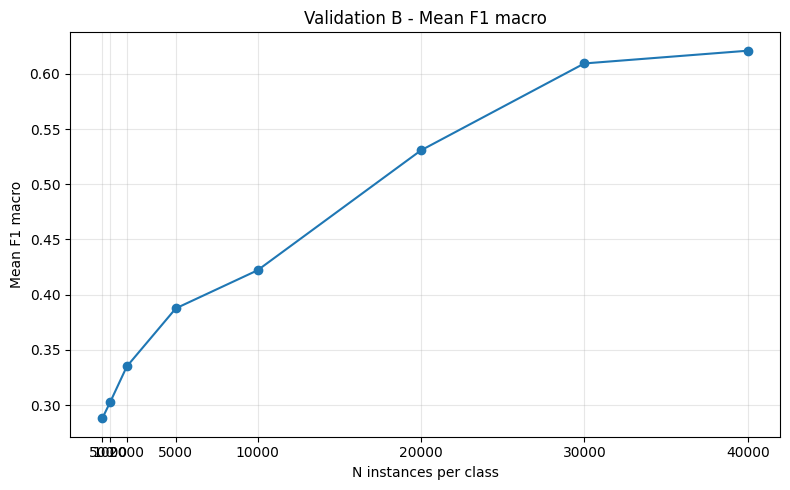

Gráfica guardada en:
/home/javier/TFG_FASE_0/04_experimentos/logs/resultados/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1/B_mean_f1_macro.png


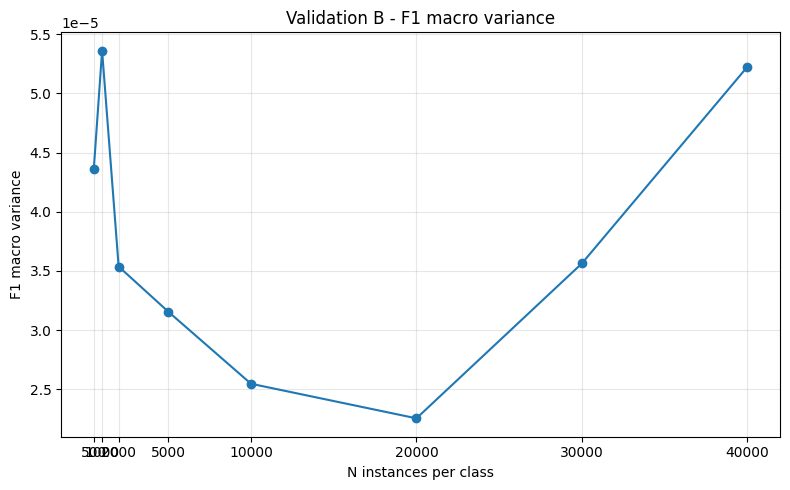

Gráfica guardada en:
/home/javier/TFG_FASE_0/04_experimentos/logs/resultados/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1/B_var_f1_macro.png


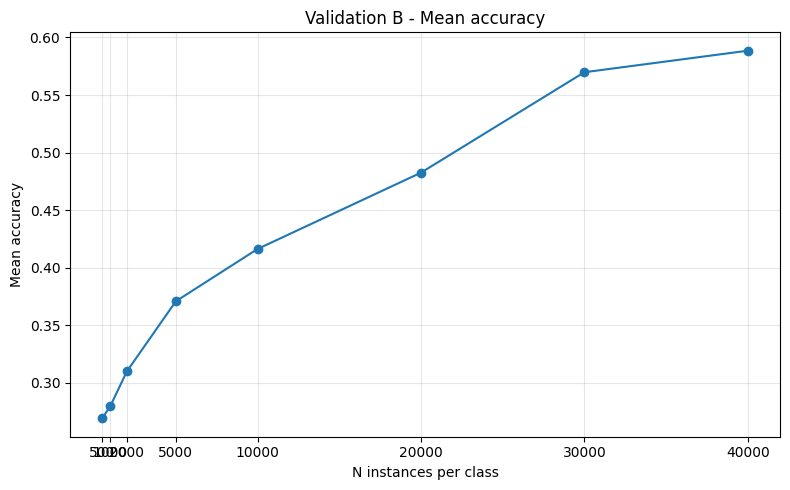

Gráfica guardada en:
/home/javier/TFG_FASE_0/04_experimentos/logs/resultados/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1/B_mean_accuracy.png


In [17]:
def plot_metrica(df, x_col, y_col, titulo, ylabel, nombre_archivo):
    plt.figure(figsize=(8, 5))
    plt.plot(df[x_col], df[y_col], marker="o")
    plt.xticks(df[x_col])
    plt.xlabel("N instances per class")
    plt.ylabel(ylabel)
    plt.title(titulo)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    ruta = RUTA_RESULTADOS / nombre_archivo
    plt.savefig(ruta, dpi=300, bbox_inches="tight")
    plt.show()

    print("Gráfica guardada en:")
    print(ruta.resolve())


# =========================
# Gráficas con métricas de B
# =========================
plot_metrica(
    df_resumen,
    "n",
    "B_f1_macro_mean",
    "Validation B - Mean F1 macro",
    "Mean F1 macro",
    "B_mean_f1_macro.png"
)

plot_metrica(
    df_resumen,
    "n",
    "B_f1_macro_var",
    "Validation B - F1 macro variance",
    "F1 macro variance",
    "B_var_f1_macro.png"
)

plot_metrica(
    df_resumen,
    "n",
    "B_accuracy_mean",
    "Validation B - Mean accuracy",
    "Mean accuracy",
    "B_mean_accuracy.png"
)

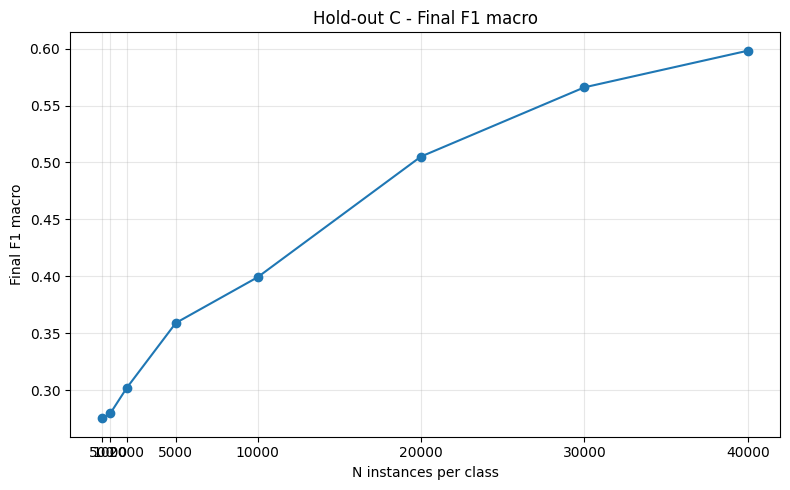

Gráfica guardada en:
/home/javier/TFG_FASE_0/04_experimentos/logs/resultados/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1/C_final_f1_macro.png


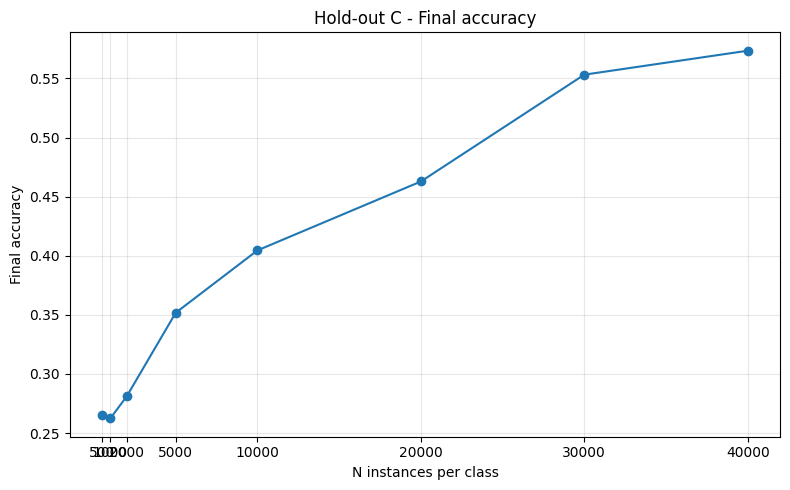

Gráfica guardada en:
/home/javier/TFG_FASE_0/04_experimentos/logs/resultados/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1/C_final_accuracy.png


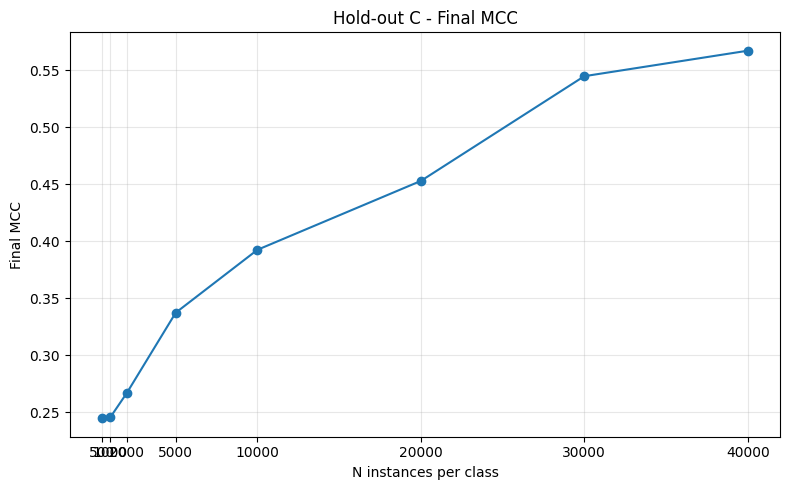

Gráfica guardada en:
/home/javier/TFG_FASE_0/04_experimentos/logs/resultados/CIC18__split__v1__fase0_StandardScaler_pca_NearMiss_SMOTE_knn__v1/C_final_mcc.png


In [18]:
# =========================
# Gráficas con métricas de C
# OJO: C ya no tiene media ni varianza.
# Es el valor único del hold-out final para cada N.
# =========================
plot_metrica(
    df_resumen,
    "n",
    "C_f1_macro",
    "Hold-out C - Final F1 macro",
    "Final F1 macro",
    "C_final_f1_macro.png"
)

plot_metrica(
    df_resumen,
    "n",
    "C_accuracy",
    "Hold-out C - Final accuracy",
    "Final accuracy",
    "C_final_accuracy.png"
)

plot_metrica(
    df_resumen,
    "n",
    "C_mcc",
    "Hold-out C - Final MCC",
    "Final MCC",
    "C_final_mcc.png"
)


In [19]:
imprimir_tabla_copiable(df_tabla_B)

μ ACCURACY	σ ACCURACY	μ PRECISION WEIGHTED	σ PRECISION WEIGHTED	μ RECALL WEIGHTED	σ RECALL WEIGHTED	μ F1 WEIGHTED	σ F1 WEIGHTED	μ PRECISION MACRO	σ PRECISION MACRO	μ RECALL MACRO	σ RECALL MACRO	μ F1 MACRO	σ F1 MACRO	μ MCC	σ MCC	μ AUC-ROC	σ AUC-ROC	μ FIT TIME	σ² FIT TIME	μ SCORE TIME	σ² SCORE TIME
0.269046	0.002628	0.753220	0.003035	0.269046	0.002628	0.300896	0.004060	0.410185	0.006264	0.567561	0.009613	0.287998	0.006607	0.248270	0.002770	0.638443	0.001962	0.002694	0.000000	1.548374	0.047705
0.279945	0.004788	0.767476	0.003808	0.279945	0.004788	0.305152	0.006270	0.432757	0.009010	0.578677	0.006445	0.303214	0.007321	0.264677	0.003840	0.640319	0.003392	0.002912	0.000000	2.157432	0.050536
0.309777	0.003556	0.807955	0.002043	0.309777	0.003556	0.343231	0.003730	0.483260	0.008045	0.632510	0.006598	0.334962	0.005947	0.294686	0.003248	0.655231	0.003569	0.004005	0.000001	4.135995	0.509904
0.370760	0.004915	0.871234	0.009003	0.370760	0.004915	0.435198	0.006571	0.535439	0.008926	0.670304	0.009274	

In [20]:
imprimir_tabla_copiable(df_tabla_C)

ACCURACY	PRECISION WEIGHTED	RECALL WEIGHTED	F1 WEIGHTED	PRECISION MACRO	RECALL MACRO	F1 MACRO	MCC	AUC-ROC	FIT TIME	SCORE TIME
0.265136	0.752430	0.265136	0.295978	0.400941	0.569526	0.275221	0.244800	0.637118	0.001672	1.708006
0.262479	0.756863	0.262479	0.290191	0.411984	0.560057	0.279804	0.245762	0.634271	0.002122	3.155718
0.281033	0.772140	0.281033	0.302910	0.434599	0.581345	0.302032	0.266850	0.639976	0.003177	6.304206
0.351796	0.855866	0.351796	0.408977	0.508269	0.653376	0.359012	0.337404	0.673518	0.010304	11.953487
0.404572	0.854902	0.404572	0.478441	0.502112	0.692257	0.399130	0.392560	0.699156	0.022031	22.325351
0.462850	0.873000	0.462850	0.540483	0.584164	0.727934	0.505146	0.452939	0.728685	0.039101	42.380410
0.553214	0.907774	0.553214	0.624436	0.613416	0.784692	0.565961	0.544749	0.776993	0.055680	53.368139
0.573486	0.913019	0.573486	0.641983	0.635884	0.800119	0.598141	0.567090	0.787711	0.054058	69.283786
